In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import pdist, squareform
import statsmodels as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg
import sys
import importlib

# python source path
sys.path.append('../Src/')

# custom python 
import z_score
import utils

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Scipy": scipy.__version__, 
    "statsmodels": sm.__version__,
    "Pingouin": pg.__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_int64 = pd.ArrowDtype(pa.int64())
arrow_bool = pd.ArrowDtype(pa.bool8())

       Library Version
0       Python  3.13.9
1       Pandas   2.3.3
2        NumPy   2.3.4
3        Scipy  1.16.3
4  statsmodels  0.14.5
5     Pingouin   0.5.5


In [2]:
# Read Arrow IPC file
with open('../Data/crime_data.arrow', 'rb') as f:
    reader = ipc.open_file(f)
    table = reader.read_all()
    
# Convert back to pandas (Arrow‑backed)
df = table.to_pandas(types_mapper=pd.ArrowDtype)
# Display
df.head()

,date,description,location_description,arrest,domestic,beat,district,ward,community_code,year,zip_code,zip_code_area,neighborhood,neighborhood_area,community_name,community_area,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,sector
0,2001-12-30 02:30:00,AUTOMOBILE,STREET,0,0,334,003,07,43,2001,60649,80526075.8505,South Shore,81812716.3904,South Shore,81812716.3958,December,Sunday,Q4,2001-Q4,Late Night,Motor Vehicle Theft,1,Grand Crossing,1
1,2001-12-24 12:30:00,FRAUD OR CONFIDENCE GAME,APARTMENT,0,0,2313,019,46,03,2001,60640,77305245.6358,Uptown,65095642.836,Uptown,65095642.7289,December,Monday,Q4,2001-Q4,Afternoon,Fraud,0,Town Hall,3
2,2001-12-31 23:00:00,FINANCIAL ID THEFT:$300 &UNDER,APARTMENT,0,0,1531,015,37,25,2001,60651,99039621.5713,Austin,170037750.826,Austin,199254203.427,December,Monday,Q4,2001-Q4,Night,Larceny – Theft,1,Austin,4
3,2001-12-23 22:30:00,AUTOMOBILE,STREET,0,0,1022,010,12,30,2001,60623,155285530.844,Little Village,127998297.819,South Lawndale,127998297.867,December,Sunday,Q4,2001-Q4,Night,Motor Vehicle Theft,1,Ogden,4
4,2001-12-31 20:00:00,PREDATORY,APARTMENT,0,0,1723,017,33,14,2001,60625,105830918.044,Albany Park,53542230.819,Albany Park,53542230.8191,December,Monday,Q4,2001-Q4,Night,Criminal Sexual Assault,1,Albany Park,5


In [3]:
# NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,469,872) ---
                       Count Percentage
neighborhood_area     116237    1.3724%
community_area        116237    1.3724%
zip_code_area         116181    1.3717%
ward                   84100    0.9929%
location_description   15338    0.1811%
community_code          9744    0.1150%
zip_code                9744    0.1150%
neighborhood            9744    0.1150%
community_name          9744    0.1150%
district                 139    0.0016%
district_location        139    0.0016%
sector                   139    0.0016%


#### Calculating the Z-score highlights specialized anomalies
- A Z-score of 3.0
    - The value is higher than about 99.87% of all values in a normal distribution 
    - It’s an extreme outlier
- A Z‑score of 2 means:
    - The value is higher than about 97.7% of all values in a normal distribution
    - That year’s count is significantly higher than the historical average
- A Z-score of -1:
    - The value is lower than about 84% of all values
    - It’s a mild decrease, not extreme

In [4]:
# Calculate z-scores
z_score = z_score.calculate_crime_zscores(df, 'fbi_code_desc', 'year')
# Display
z_score.head()

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,1.426698,1.291884,0.980297,0.943692,0.428545,0.288375,0.054461,-0.021427,-0.244628,-0.889231,-0.997260,-1.250816,-1.790961,-1.729357,-1.601687,-0.500862,-0.429438,-0.242842,-0.386583,-0.008035,0.864232,0.899052,1.284742,1.456160,0.174989
Aggravated Battery,2.734977,2.265772,1.203024,0.832353,0.753761,0.627858,0.685336,0.548875,0.289640,0.012027,-0.390706,-0.545935,-1.082001,-1.104288,-0.931856,-0.514655,-0.608496,-0.651897,-0.603412,-0.422769,-0.411821,-0.745347,-0.515437,-0.477509,-0.947496
Arson,2.182703,2.288885,1.899550,1.004585,0.564687,0.741658,0.670870,0.327041,0.185465,-0.289827,-0.380840,-0.557811,-1.088722,-0.921864,-0.638712,-0.320165,-0.684218,-1.043215,-1.028046,0.043889,-0.249377,-0.795457,-0.335334,-0.497135,-1.078609
Burglary,1.034278,0.985417,0.927185,0.853082,0.970422,0.823091,0.889821,1.059770,1.128375,1.085263,1.110005,0.638146,0.019579,-0.395922,-0.568996,-0.430912,-0.591864,-0.748568,-1.011990,-1.121957,-1.384129,-1.267414,-1.281035,-1.260041,-1.461606
Criminal Sexual Assault,2.036762,2.178314,0.938319,0.638229,0.445719,-0.131813,0.264532,-0.165786,-0.782952,-1.105690,-0.562131,-0.760304,-1.496374,-1.100028,-0.664048,0.224898,0.926995,1.289368,0.541974,-1.847422,-0.397931,0.077684,0.264532,-0.262041,-0.550807


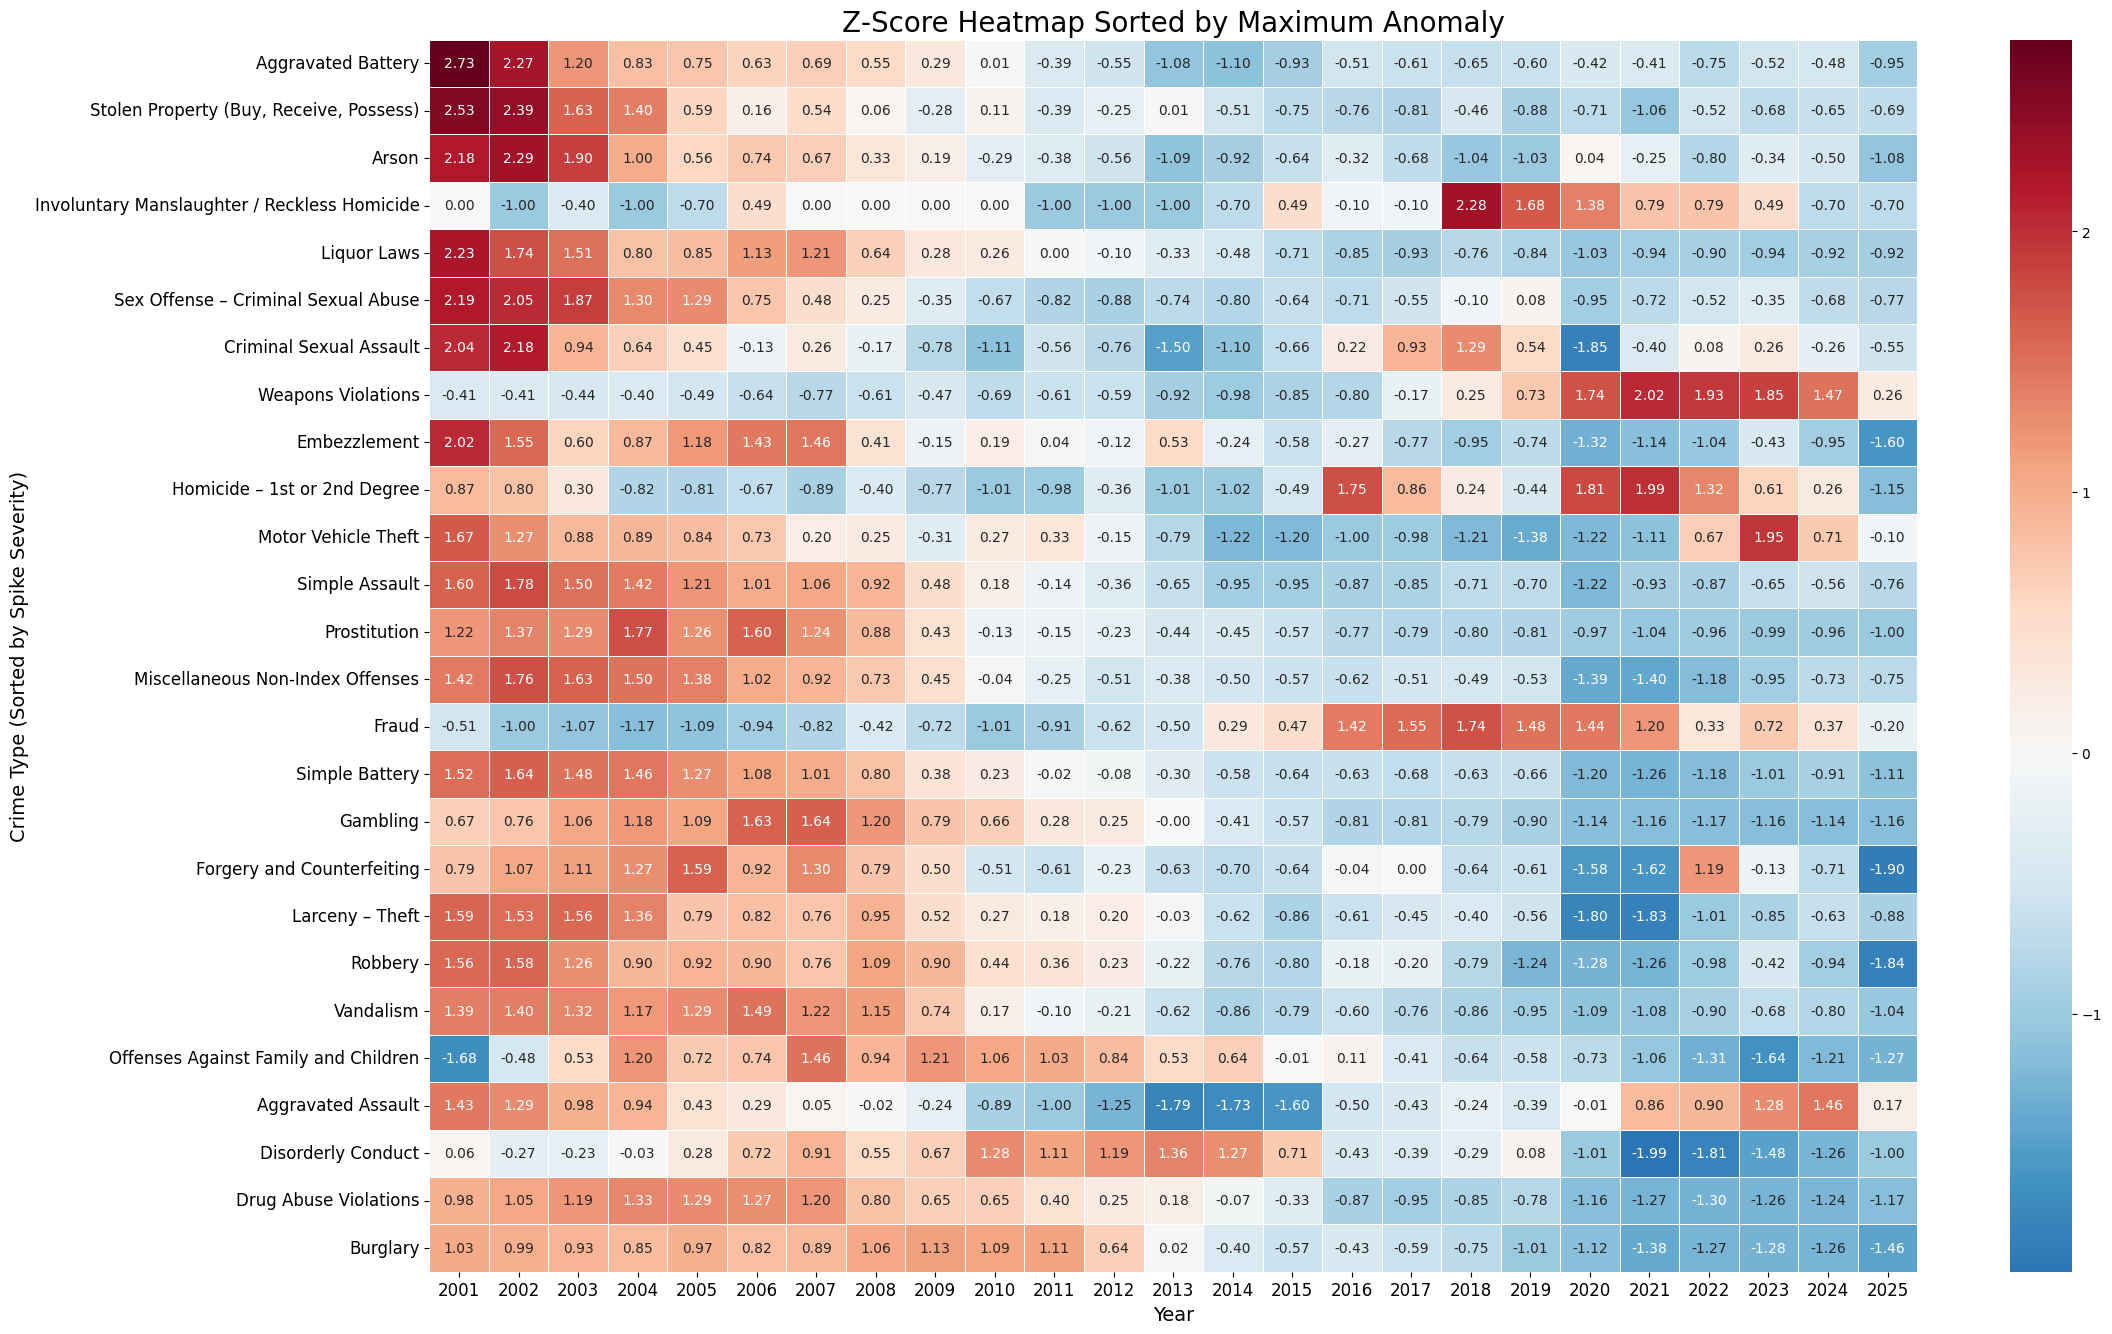

In [5]:
# Sort columns by maximum z‑score (years with biggest spikes first)
# z_sorted_cols = z_pivot[z_pivot.max().sort_values(ascending=False).index]

# Sort crime types by their highest z-score across all years 
z_sorted = z_score.loc[z_score.max(axis=1).sort_values(ascending=False).index]

# Create the Heatmap
plt.figure(figsize=(24, 16))
sns.heatmap(
    z_sorted,
    cmap="RdBu_r",          # Red for high Z-scores, Blue for low
    center=0,               # White represents the mean
    annot=True,             # Change to False if you don't want to see the numbers
    fmt=".2f",              # format as integers
    annot_kws={"size": 10}, # change font size here
    linewidths=.5
)
plt.title("Z‑Score Heatmap Sorted by Maximum Anomaly", fontsize=20)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Crime Type (Sorted by Spike Severity)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# Save the figure with high resolution and tight cropping
# plt.savefig("../Image/cluster_Heatmap_z-score_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

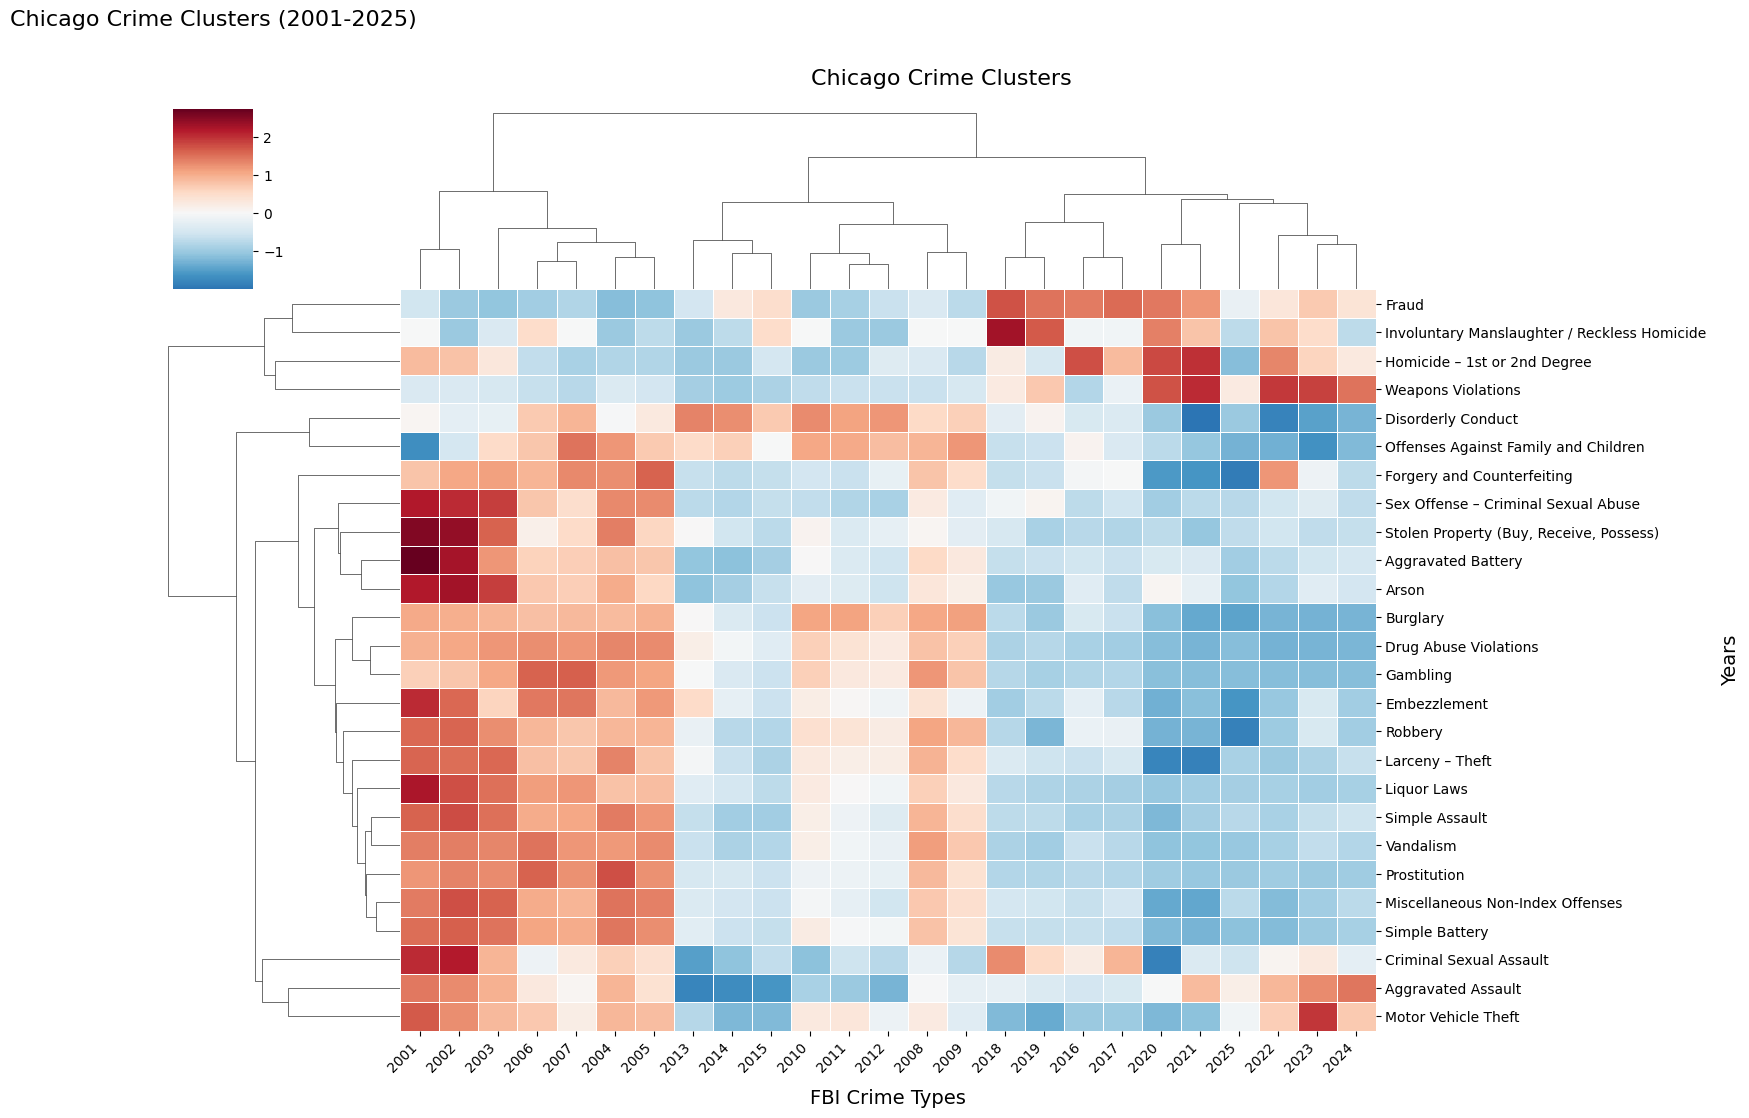

In [6]:
# Create the clustermap
g = sns.clustermap(
    z_score, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)

# Save the figure with high resolution and tight cropping
# plt.savefig("../Image/cluster_Heatmap_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

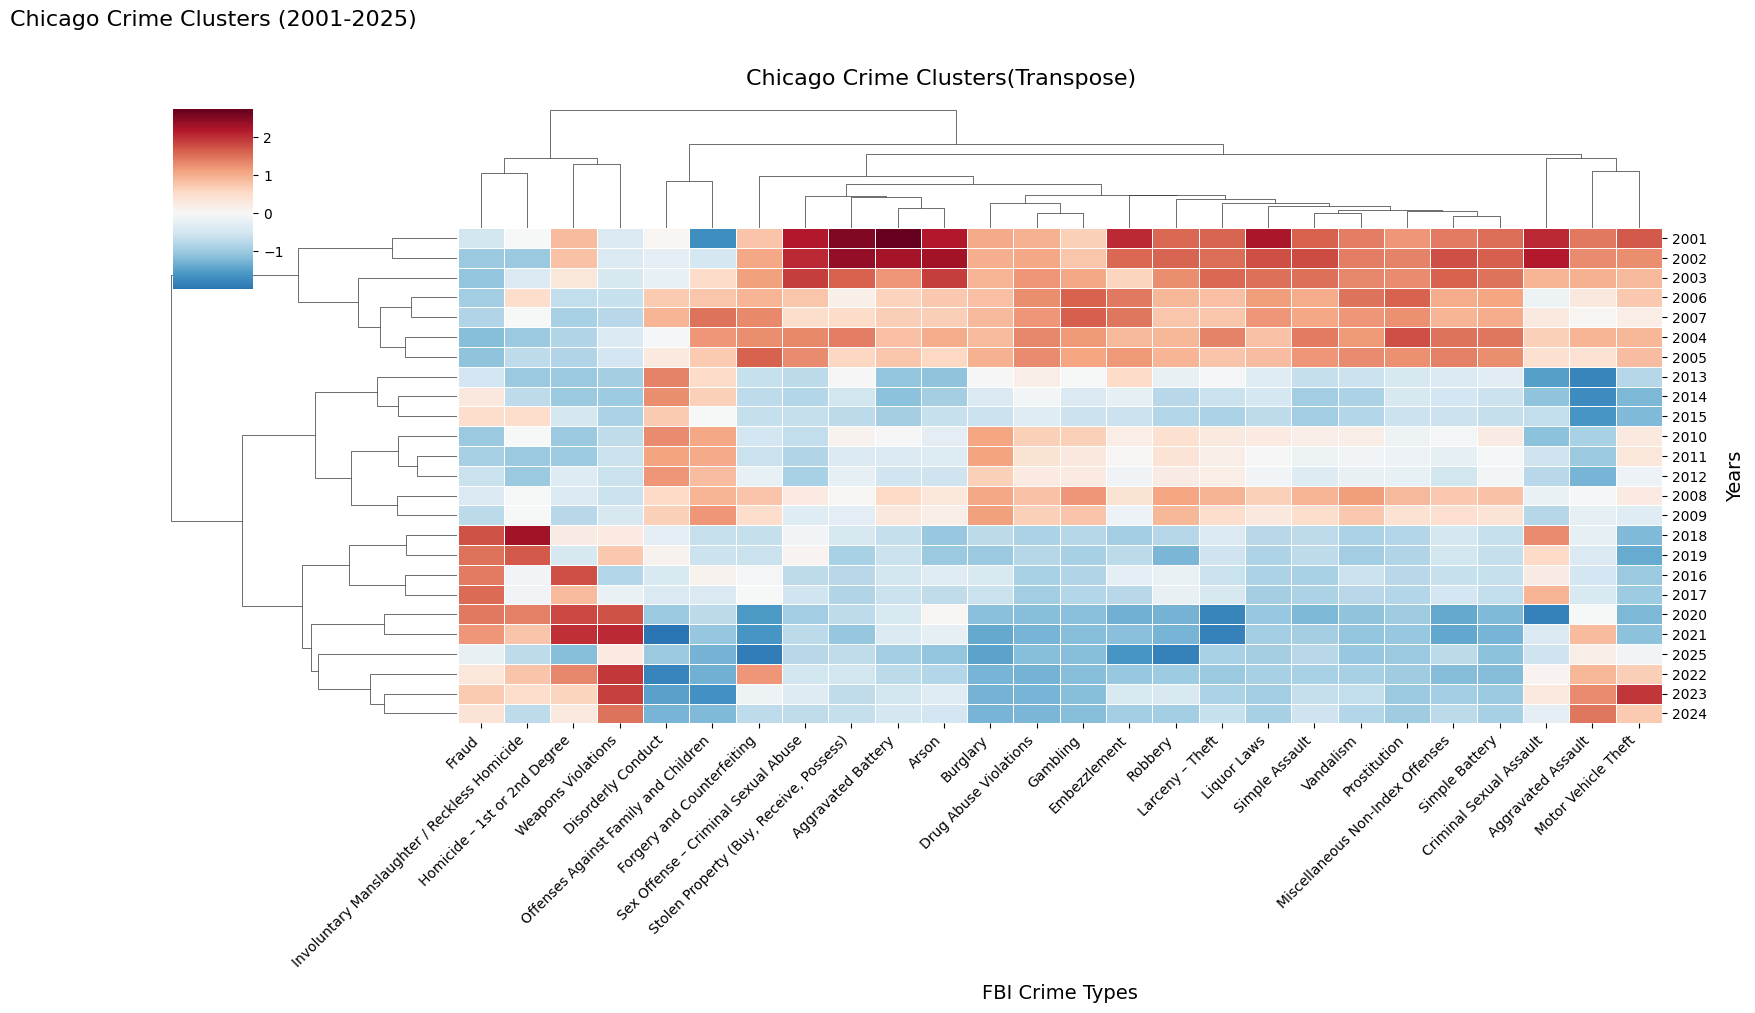

In [7]:
# Create the rotated clustermap
g = sns.clustermap(
    z_score.T, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
# Labels
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters(Transpose)", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=14)
# Save the figure with high resolution and tight cropping
# plt.savefig("../Image/cluster_Heatmap_rotate_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

**Note:**
1. The Color Intensity (The Values)
* Since you are using Z-scores, look at the color first:
  - Deep Red: The crime count for that specific year was significantly above its historical average.
    - Deep Blue: The crime count for that specific year was significantly below its historical average.
    - White/Light Colors: The crime count was "normal" or very close to the 25-year mean.

2. The Dendrogram (The "Tree" Structure)
* The branches on the top (or side) tell you how similar items are.
* Close Neighbors: If two crime types are connected by a short "U-shaped" branch, they have very similar patterns over the 25-year period.
* Branch Length: The longer the vertical lines of the branch before they join, the less similar those two groups are.

3. Reading the "Clusters" (The Groups)
*  The "Legacy" Cluster: Crimes that were rampant in the early 2000s but have since crashed (like Drug Abuse Violations or Prostitution). These will be Red on the top-left and deep Blue on the bottom-right.
* The "Resilient" Cluster: Crimes that have stayed consistently high or "Red" for almost the entire 25 years. These are the persistent issues Chicago faces.
* The "Modern Surge" Cluster: Crimes that were blue for years but have recently turned bright Red (like Motor Vehicle Theft and Weapons Violations).

4. Reading the X and Y Axis Together
* To find a specific "Anomaly," look for a single "pop" of color that breaks a trend.
* Vertical Red Streaks: If you see a vertical column of red across many crimes for a single year (like 2020), it suggests an External Event (like the Pandemic or civil unrest) affected almost everything at once.
* Horizontal Red Streaks: If one crime type is red across many years, it shows a long-term sustained increase for that specific category.

5. Why the "Rotation" Helps
* By rotating the plot, you can now scan horizontally to see which crimes behave similarly in the same year, and scan vertically to see how a single crime's "fortune" has changed from 2001 to 2025.

**Tip: The "Pivot Point"**
* Look for where the colors flip from Blue to Red. In Chicago's data, there is often a "pivot" around 2016 and 2020. These are the years where the "old" patterns of crime significantly shifted into the "modern" patterns we see today.

In [8]:
z_score.T.head()

fbi_code_desc,Aggravated Assault,Aggravated Battery,Arson,Burglary,Criminal Sexual Assault,Disorderly Conduct,Drug Abuse Violations,Embezzlement,Forgery and Counterfeiting,Fraud,Gambling,Homicide – 1st or 2nd Degree,Involuntary Manslaughter / Reckless Homicide,Larceny – Theft,Liquor Laws,Miscellaneous Non-Index Offenses,Motor Vehicle Theft,Offenses Against Family and Children,Prostitution,Robbery,Sex Offense – Criminal Sexual Abuse,Simple Assault,Simple Battery,"Stolen Property (Buy, Receive, Possess)",Vandalism,Weapons Violations
year,,,,,,,,,,,,,,,,,,,,,,,,,,
2001,1.426698,2.734977,2.182703,1.034278,2.036762,0.056858,0.981619,2.018299,0.786856,-0.514709,0.666581,0.868322,0.000000,1.585812,2.225295,1.417810,1.671029,-1.677568,1.220341,1.556531,2.190257,1.599843,1.522529,2.528970,1.390687,-0.407988
2002,1.291884,2.265772,2.288885,0.985417,2.178314,-0.271316,1.050354,1.554251,1.067876,-1.003537,0.757948,0.804755,-0.996913,1.529952,1.738842,1.757001,1.271381,-0.483570,1.365664,1.578470,2.047715,1.784858,1.642698,2.394030,1.396863,-0.406492
2003,0.980297,1.203024,1.899550,0.927185,0.938319,-0.226084,1.192205,0.595219,1.113795,-1.074824,1.063828,0.304167,-0.401741,1.561588,1.514157,1.625191,0.882074,0.528013,1.291861,1.259818,1.869034,1.500017,1.479337,1.625915,1.322183,-0.441887
2004,0.943692,0.832353,1.004585,0.853082,0.638229,-0.027832,1.333854,0.873648,1.273590,-1.174844,1.183003,-0.816197,-0.996913,1.362430,0.803019,1.498788,0.891265,1.202401,1.771957,0.897555,1.300872,1.417138,1.460402,1.397556,1.174024,-0.398516
2005,0.428545,0.753761,0.564687,0.970422,0.445719,0.279169,1.291757,1.183013,1.591345,-1.093009,1.087663,-0.808251,-0.699327,0.791574,0.846647,1.383336,0.840714,0.721485,1.257623,0.916016,1.288826,1.213636,1.272969,0.587920,1.285043,-0.494231


#### Clustering

In [21]:
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)

# Raw linkage matrix, and this matrix tells the entire story of your dendrogram’s structure
#  cluster A, cluster B, merge height, cluster size
Z = g.dendrogram_col.linkage

# print
print (Z)

[[15.     22.      0.8366  2.    ]
 [21.     24.      1.0288  2.    ]
 [ 6.     10.      1.0372  2.    ]
 [18.     26.      1.1784  3.    ]
 [27.     29.      1.209   5.    ]
 [ 1.      2.      1.3467  2.    ]
 [14.     30.      1.5009  6.    ]
 [ 3.     28.      1.6691  3.    ]
 [13.     32.      1.6799  7.    ]
 [19.     34.      1.9824  8.    ]
 [23.     31.      2.0901  3.    ]
 [20.     36.      2.1495  4.    ]
 [ 7.     35.      2.2095  9.    ]
 [33.     38.      2.2471 12.    ]
 [37.     39.      3.0022 16.    ]
 [ 5.     17.      3.1625  2.    ]
 [ 8.     40.      3.5324 17.    ]
 [ 9.     12.      3.7346  2.    ]
 [ 0.     16.      3.9058  2.    ]
 [11.     25.      4.3386  2.    ]
 [43.     45.      4.734   4.    ]
 [ 4.     44.      4.777   3.    ]
 [42.     47.      5.0385 20.    ]
 [41.     48.      5.705  22.    ]
 [46.     49.      8.0516 26.    ]]


The output above is a raw linkage matrix from the `g.dendrogram_col.linkage` object, and this matrix tells the entire story of our dendrogram’s structure. The significant jump from 5.70 to 8.05 indicates we have located the "elbow" of the dendrogram, where the mathematical cohesion of the groups breaks down, and at this stage, we are no longer joining "similar" crime types but rather forcing distinct behavioral patterns into a single, over-generalized category. 

In [22]:
# Calculate the inconsistent statistics
from scipy.cluster.hierarchy import inconsistent

# Inconsistency coefficient column
I = inconsistent(Z, 2)   # depth=2 is the standard choice

# print
print(I)

[[0.8366 0.     1.     0.    ]
 [1.0288 0.     1.     0.    ]
 [1.0372 0.     1.     0.    ]
 [1.0075 0.2417 2.     0.7071]
 [1.1388 0.0964 3.     0.7288]
 [1.3467 0.     1.     0.    ]
 [1.355  0.2064 2.     0.7071]
 [1.3531 0.4468 2.     0.7071]
 [1.5904 0.1266 2.     0.7071]
 [1.8312 0.2139 2.     0.7071]
 [1.7184 0.5257 2.     0.7071]
 [2.1198 0.042  2.     0.7071]
 [2.096  0.1606 2.     0.7071]
 [2.0419 0.3234 3.     0.6345]
 [2.4663 0.4667 3.     1.1484]
 [3.1625 0.     1.     0.    ]
 [3.2673 0.3749 2.     0.7071]
 [3.7346 0.     1.     0.    ]
 [3.9058 0.     1.     0.    ]
 [4.3386 0.     1.     0.    ]
 [4.2691 0.5033 3.     0.9238]
 [4.3414 0.616  2.     0.7071]
 [4.4493 0.8047 3.     0.7322]
 [4.6353 1.3183 3.     0.8114]
 [6.1636 1.7057 3.     1.1069]]


- Each row of the inconsistency matrix has four values:
    - Mean of the merge heights in the local neighborhood
    - Standard deviation of those heights
    - Number of links used in the local neighborhood
    - Inconsistency coefficient : 
$
\text{inconsistency}_i = \frac{Z_{[i,2]} - \text{Local mean}}{\text{local Std}}
$


**The fourth column is the one that matters for evaluating cluster stability.**

- 0.0 $\rightarrow$ the merge height is identical to the local average $\rightarrow$ extremely natural merge
- 0.6 – 0.8 $\rightarrow$ mild deviation $\rightarrow$ still natural, but slightly broader merges
- 0.9 – 1.2 $\rightarrow$ noticeable deviation $\rightarrow$ the algorithm is merging groups that are less similar
- $\gt$ 2.0 (not present in your data) $\rightarrow$ strongly unnatural merges $\rightarrow$ forced merges across major cluster boundaries

Our matrix never exceeds 1.15, indicating that the dataset has a smooth hierarchical structure with no abrupt discontinuities.

In [25]:
# Inspect inconsistency
heights = Z[:, 2] 
incons = I[:, 3]

heights, incons

(array([0.8366, 1.0288, 1.0372, 1.1784, 1.209 , 1.3467, 1.5009, 1.6691, 1.6799, 1.9824, 2.0901,
        2.1495, 2.2095, 2.2471, 3.0022, 3.1625, 3.5324, 3.7346, 3.9058, 4.3386, 4.734 , 4.777 ,
        5.0385, 5.705 , 8.0516]),
 array([0.    , 0.    , 0.    , 0.7071, 0.7288, 0.    , 0.7071, 0.7071, 0.7071, 0.7071, 0.7071,
        0.7071, 0.7071, 0.6345, 1.1484, 0.    , 0.7071, 0.    , 0.    , 0.    , 0.9238, 0.7071,
        0.7322, 0.8114, 1.1069]))

In [28]:
# Find merges with higher inconsistency,
idx_high = np.where(incons > 1.0)[0]
critical_heights = heights[idx_high]
# Critical_heights are where merges start to be “stretched”.
critical_heights

array([3.0022, 8.0516])

The next few merges (3.16, 3.53, 3.73, 3.90) all have an inconsistency well below 1.0; therefore, they are consistent and don’t indicate a structural break. Three real structural changes begin at 4.734 and finally break down at 8.0516 (heights), with an inconsistency value of 1.1069 (incons).
Let's select between 4.3 and 5.7, which is before a structural break.

In [46]:
z_score.head()

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,1.426698,1.291884,0.980297,0.943692,0.428545,0.288375,0.054461,-0.021427,-0.244628,-0.889231,-0.997260,-1.250816,-1.790961,-1.729357,-1.601687,-0.500862,-0.429438,-0.242842,-0.386583,-0.008035,0.864232,0.899052,1.284742,1.456160,0.174989
Aggravated Battery,2.734977,2.265772,1.203024,0.832353,0.753761,0.627858,0.685336,0.548875,0.289640,0.012027,-0.390706,-0.545935,-1.082001,-1.104288,-0.931856,-0.514655,-0.608496,-0.651897,-0.603412,-0.422769,-0.411821,-0.745347,-0.515437,-0.477509,-0.947496
Arson,2.182703,2.288885,1.899550,1.004585,0.564687,0.741658,0.670870,0.327041,0.185465,-0.289827,-0.380840,-0.557811,-1.088722,-0.921864,-0.638712,-0.320165,-0.684218,-1.043215,-1.028046,0.043889,-0.249377,-0.795457,-0.335334,-0.497135,-1.078609
Burglary,1.034278,0.985417,0.927185,0.853082,0.970422,0.823091,0.889821,1.059770,1.128375,1.085263,1.110005,0.638146,0.019579,-0.395922,-0.568996,-0.430912,-0.591864,-0.748568,-1.011990,-1.121957,-1.384129,-1.267414,-1.281035,-1.260041,-1.461606
Criminal Sexual Assault,2.036762,2.178314,0.938319,0.638229,0.445719,-0.131813,0.264532,-0.165786,-0.782952,-1.105690,-0.562131,-0.760304,-1.496374,-1.100028,-0.664048,0.224898,0.926995,1.289368,0.541974,-1.847422,-0.397931,0.077684,0.264532,-0.262041,-0.550807


In [30]:
z_score.T.head()

fbi_code_desc,Aggravated Assault,Aggravated Battery,Arson,Burglary,Criminal Sexual Assault,Disorderly Conduct,Drug Abuse Violations,Embezzlement,Forgery and Counterfeiting,Fraud,Gambling,Homicide – 1st or 2nd Degree,Involuntary Manslaughter / Reckless Homicide,Larceny – Theft,Liquor Laws,Miscellaneous Non-Index Offenses,Motor Vehicle Theft,Offenses Against Family and Children,Prostitution,Robbery,Sex Offense – Criminal Sexual Abuse,Simple Assault,Simple Battery,"Stolen Property (Buy, Receive, Possess)",Vandalism,Weapons Violations
year,,,,,,,,,,,,,,,,,,,,,,,,,,
2001,1.426698,2.734977,2.182703,1.034278,2.036762,0.056858,0.981619,2.018299,0.786856,-0.514709,0.666581,0.868322,0.000000,1.585812,2.225295,1.417810,1.671029,-1.677568,1.220341,1.556531,2.190257,1.599843,1.522529,2.528970,1.390687,-0.407988
2002,1.291884,2.265772,2.288885,0.985417,2.178314,-0.271316,1.050354,1.554251,1.067876,-1.003537,0.757948,0.804755,-0.996913,1.529952,1.738842,1.757001,1.271381,-0.483570,1.365664,1.578470,2.047715,1.784858,1.642698,2.394030,1.396863,-0.406492
2003,0.980297,1.203024,1.899550,0.927185,0.938319,-0.226084,1.192205,0.595219,1.113795,-1.074824,1.063828,0.304167,-0.401741,1.561588,1.514157,1.625191,0.882074,0.528013,1.291861,1.259818,1.869034,1.500017,1.479337,1.625915,1.322183,-0.441887
2004,0.943692,0.832353,1.004585,0.853082,0.638229,-0.027832,1.333854,0.873648,1.273590,-1.174844,1.183003,-0.816197,-0.996913,1.362430,0.803019,1.498788,0.891265,1.202401,1.771957,0.897555,1.300872,1.417138,1.460402,1.397556,1.174024,-0.398516
2005,0.428545,0.753761,0.564687,0.970422,0.445719,0.279169,1.291757,1.183013,1.591345,-1.093009,1.087663,-0.808251,-0.699327,0.791574,0.846647,1.383336,0.840714,0.721485,1.257623,0.916016,1.288826,1.213636,1.272969,0.587920,1.285043,-0.494231


In [41]:
range(len(T))

range(0, 3)

In [45]:
# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)
z_score_rotated = z_score.T 
T_values = [4.3, 4.5, 5.0]

for T in T_values:
    # Get the linkage and clusters
    linkage = g.dendrogram_col.linkage 
    # clusters = fcluster(linkage, t=distance_threshold, criterion='distance')
    clusters = fcluster(linkage, t=T, criterion='distance')
    
    
    # Create the mapping using .columns instead of .index
    # This matches the names on the X-axis of your rotated plot
    crime_groups = pd.DataFrame({
        'fbi_code_desc': z_score_rotated.columns, 
        'cluster_id': clusters
    }).sort_values('cluster_id')
    
    # Display the members
    for cluster_num in range(1, (len(np.unique(clusters))) + 1):
        members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
        print(f"--- Cluster {cluster_num} & {T} value ---")
        print("\n".join([f"  • {m}" for m in members]))
        print("-" * 30)
    print("\n")

--- Cluster 1 & 4.3 value ---
  • Involuntary Manslaughter / Reckless Homicide
  • Fraud
------------------------------
--- Cluster 2 & 4.3 value ---
  • Homicide – 1st or 2nd Degree
------------------------------
--- Cluster 3 & 4.3 value ---
  • Weapons Violations
------------------------------
--- Cluster 4 & 4.3 value ---
  • Disorderly Conduct
  • Offenses Against Family and Children
------------------------------
--- Cluster 5 & 4.3 value ---
  • Liquor Laws
  • Sex Offense – Criminal Sexual Abuse
  • Robbery
  • Prostitution
  • Stolen Property (Buy, Receive, Possess)
  • Miscellaneous Non-Index Offenses
  • Burglary
  • Larceny – Theft
  • Vandalism
  • Aggravated Battery
  • Gambling
  • Arson
  • Forgery and Counterfeiting
  • Embezzlement
  • Drug Abuse Violations
  • Simple Assault
  • Simple Battery
------------------------------
--- Cluster 6 & 4.3 value ---
  • Aggravated Assault
  • Motor Vehicle Theft
------------------------------
--- Cluster 7 & 4.3 value ---
  • Cri

In [34]:
# Use the order generated by the clustermap columns
labels = list(g.data2d.columns)   

# Find row/col indices for target crime labels
# i and j correctly point to the positions in the distance matrix
i = labels.index("Homicide – 1st or 2nd Degree")
j = labels.index("Weapons Violations")

T = [4.3, 4.5, 5.0]

# Build a full n×n distance matrix for all crime types
dist_matrix = squareform(pdist(g.data2d.T, metric='euclidean'))
# Extract distance between these two specific points
# distance_threshold = dist_matrix[i, j]
# print("distance_threshold: ", distance_threshold)

# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)
z_score_rotated = z_score.T 

# Get the linkage and clusters
linkage = g.dendrogram_col.linkage 
# clusters = fcluster(linkage, t=distance_threshold, criterion='distance')
clusters = fcluster(linkage, t=T, criterion='distance')


# Create the mapping using .columns instead of .index
# This matches the names on the X-axis of your rotated plot
crime_groups = pd.DataFrame({
    'fbi_code_desc': z_score_rotated.columns, 
    'cluster_id': clusters
}).sort_values('cluster_id')

# Display the members
for cluster_num in range(1, (len(np.unique(clusters))) + 1):
    members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
    print(f"--- Cluster {cluster_num} & {T} value ---")
    print("\n".join([f"  • {m}" for m in members]))
    print("-" * 30)

distance_threshold:  4.338576052450445
--- Cluster 1 ---
  • Involuntary Manslaughter / Reckless Homicide
  • Homicide – 1st or 2nd Degree
  • Fraud
  • Weapons Violations
------------------------------
--- Cluster 2 ---
  • Disorderly Conduct
  • Offenses Against Family and Children
------------------------------
--- Cluster 3 ---
  • Liquor Laws
  • Sex Offense – Criminal Sexual Abuse
  • Robbery
  • Prostitution
  • Stolen Property (Buy, Receive, Possess)
  • Miscellaneous Non-Index Offenses
  • Burglary
  • Larceny – Theft
  • Vandalism
  • Aggravated Battery
  • Gambling
  • Arson
  • Forgery and Counterfeiting
  • Embezzlement
  • Drug Abuse Violations
  • Simple Assault
  • Simple Battery
------------------------------
--- Cluster 4 ---
  • Criminal Sexual Assault
  • Motor Vehicle Theft
  • Aggravated Assault
------------------------------


In [37]:
from scipy.cluster.hierarchy import inconsistent
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)

inc = inconsistent(linkage)

# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
    
print(inc)
print(crime_groups)

[[0.8366 0.     1.     0.    ]
 [1.0288 0.     1.     0.    ]
 [1.0372 0.     1.     0.    ]
 [1.0075 0.2417 2.     0.7071]
 [1.1388 0.0964 3.     0.7288]
 [1.3467 0.     1.     0.    ]
 [1.355  0.2064 2.     0.7071]
 [1.3531 0.4468 2.     0.7071]
 [1.5904 0.1266 2.     0.7071]
 [1.8312 0.2139 2.     0.7071]
 [1.7184 0.5257 2.     0.7071]
 [2.1198 0.042  2.     0.7071]
 [2.096  0.1606 2.     0.7071]
 [2.0419 0.3234 3.     0.6345]
 [2.4663 0.4667 3.     1.1484]
 [3.1625 0.     1.     0.    ]
 [3.2673 0.3749 2.     0.7071]
 [3.7346 0.     1.     0.    ]
 [3.9058 0.     1.     0.    ]
 [4.3386 0.     1.     0.    ]
 [4.2691 0.5033 3.     0.9238]
 [4.3414 0.616  2.     0.7071]
 [4.4493 0.8047 3.     0.7322]
 [4.6353 1.3183 3.     0.8114]
 [6.1636 1.7057 3.     1.1069]]
                                   fbi_code_desc  cluster_id
9                                          Fraud           1
12  Involuntary Manslaughter / Reckless Homicide           2
11                  Homicide – 1st or 2nd

In [35]:
# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)
z_score_rotated = z_score.T 
cluster = 2

# Get the linkage and clusters
linkage = g.dendrogram_col.linkage 
clusters = fcluster(linkage, t=cluster, criterion='maxclust')

# Create the mapping using .columns instead of .index
# This matches the names on the X-axis of your rotated plot
crime_groups = pd.DataFrame({
    'fbi_code_desc': z_score_rotated.columns, 
    'cluster_id': clusters
}).sort_values('cluster_id')

# Display the members
for cluster_num in range(1, cluster + 1):
    members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
    print(f"--- Cluster {cluster_num} ---")
    print("\n".join([f"  • {m}" for m in members]))
    print("-" * 30)

--- Cluster 1 ---
  • Involuntary Manslaughter / Reckless Homicide
  • Homicide – 1st or 2nd Degree
  • Fraud
  • Weapons Violations
------------------------------
--- Cluster 2 ---
  • Criminal Sexual Assault
  • Stolen Property (Buy, Receive, Possess)
  • Simple Battery
  • Simple Assault
  • Sex Offense – Criminal Sexual Abuse
  • Robbery
  • Prostitution
  • Offenses Against Family and Children
  • Motor Vehicle Theft
  • Miscellaneous Non-Index Offenses
  • Liquor Laws
  • Larceny – Theft
  • Vandalism
  • Aggravated Battery
  • Gambling
  • Arson
  • Forgery and Counterfeiting
  • Embezzlement
  • Drug Abuse Violations
  • Disorderly Conduct
  • Burglary
  • Aggravated Assault
------------------------------


In [32]:
clusters

array([5, 4, 4, 4, 6, 3, 4, 4, 4, 1, 4, 2, 1, 4, 4, 4, 5, 3, 4, 4, 4, 4, 4, 4, 4, 2], dtype=int32)

In [12]:
crime_groups.head()

,fbi_code_desc,cluster_id
12,Involuntary Manslaughter / Reckless Homicide,1
9,Fraud,1
11,Homicide – 1st or 2nd Degree,2
25,Weapons Violations,2
5,Disorderly Conduct,3


In [11]:
# # Define Names Mapping
# cluster_names = {
#     1: "C1: Manslaughter/Fraud",
#     2: "C2: Homicide",
#     3: "C3: Weapons Violations",
#     4: "C4: Disorderly/Family",
#     5: "C5: Legacy/Declining",
#     6: "C6: Aggravated Assault",
#     7: "C7: Motor Vehicle Theft",
#     8: "C8: Criminal Sexual Assault"
# }
# cluster_trends['story'] = cluster_trends['cluster_id'].map(cluster_names)

# Pre-calculate values to avoid filtering inside the loop
# This ensures we only iterate through the axes and relevant data slices
grouped = cluster_trends.groupby('story')

# Create the grid
g = sns.FacetGrid(
    cluster_trends, col="story", col_wrap=4, hue="story",
    height=4, aspect=1.0, sharex=False
)

# Map primary elements
g.map(plt.plot, "year", "z_score", linewidth=2)
g.map(plt.axhline, y=0, color='black', linestyle='--', alpha=0.4)
g.set_titles("{col_name}")

years = sorted(cluster_trends['year'].unique())

# Iterate using zip to link axes with grouped data efficiently
for (story_name, facet_data), ax in zip(grouped, g.axes.flat):
    
    if not facet_data.empty:
        # Using idxmax() on the slice is much faster than filtering the whole DF again
        max_row = facet_data.loc[facet_data['z_score'].idxmax()]
        max_year, max_z = max_row['year'], max_row['z_score']
        
        # Draw vertical line
        ax.axvline(x=max_year, color='red', linestyle='-', alpha=0.7, linewidth=1.5)
        
        # Annotate
        ax.annotate(
            f'{max_z:.2f}', 
            xy=(max_year, max_z), 
            xytext=(5, 5), 
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.6, edgecolor='none'),
            arrowprops=dict(arrowstyle='->', color='red', alpha=0.6),
            fontsize=9, fontweight='bold'
        )
    
    # Standardize ticks and labels
    ax.set_xticks(years[::2])
    ax.set_xticklabels(years[::2], rotation=45, ha='right')
    ax.set_xlabel("Year")
    ax.set_ylabel("Z-Score")

# Final Layout
g.fig.subplots_adjust(hspace=0.4, wspace=0.2)
# Save the figure with high resolution and tight cropping
g.savefig("../Image/cluster_trends_analysis.png", dpi=600, bbox_inches='tight')
plt.show()

NameError: name 'cluster_trends' is not defined